# 데이터 마트 구성
## Layer 1 — 정책 관점으로 재구성

## 목적

`00_lgd_estimation.ipynb`에서는 손실 규모(LGD)를 다뤘다면, 이 노트북은 **PD 추정과 한도 정책 산정에 함께 쓸 수 있는 분석 기준 테이블**을 만드는 단계입니다.

원본 데이터는 대출 신청 건 단위지만, 실제 의사결정은 고객에게 얼마를 빌려줄 것인가라는 질문에 답해야 하므로, 분석 단위를 고객으로 재정의해야 합니다. 신청 건과 고객은 일대일로 대응하지 않기 때문에, 고객 기준의 분석 테이블을 만들어 PD 추정과 한도 정책 산정에 공통으로 활용합니다.

여기에 더해 `application_train`(현재 신청 정보), `bureau`(외부 신용기관 이력), `installments_payments`(과거 납부 이력), `previous_application`(Home Credit 내 이전 대출 이력)은 모두 고객 1명에 대해 여러 행이 달릴 수 있는  1:N 관계로 흩어져 있어, 이 4개 테이블을 고객 기준으로 집계·통합하는 작업을 합니다. 이를 통해 개별 신호를 고객 한 명의 위험 프로파일로 재구성하고, 신호가 특정 신청 건에 종속되거나 유실되지 않도록 합니다.

## Step 1. 시점 기반 분할 여부 확인

Train/Validation을 나눌 때 일반적으로는 시간 순서를 기준으로 나눠 미래 정보 누수를 막습니다. 이 데이터셋에서 그것이 가능한지 먼저 확인합니다.

In [1]:
import pandas as pd
import numpy as np

app = pd.read_csv('../data/application_train.csv')

days_cols = [c for c in app.columns if 'DAYS' in c]
for col in days_cols:
    print(f"{col:25s}: null {app[col].isna().sum():>6}개, "
          f"min {app[col].min():>10.0f}, max {app[col].max():>10.0f}")

DAYS_BIRTH               : null      0개, min     -25229, max      -7489
DAYS_EMPLOYED            : null      0개, min     -17912, max     365243
DAYS_REGISTRATION        : null      0개, min     -24672, max          0
DAYS_ID_PUBLISH          : null      0개, min      -7197, max          0
DAYS_LAST_PHONE_CHANGE   : null      1개, min      -4292, max          0


모든 `DAYS_*` 컬럼이 음수 범위이며, 컬럼 정의상 **신청일 기준 상대적 일수**입니다(예: `DAYS_BIRTH`=-10000은 "신청일로부터 10000일 전에 태어남"). 절대 날짜가 없어 이 컬럼만으로는 고객 간 신청 순서를 복원하기 어렵습니다. 

다음으로 `SK_ID_CURR`가 고객 발급 순서를 어느 정도 반영하는지 확인하고 이를 시간 축의 대안 proxy로 사용할 수 있는지 검토합니다.

In [2]:
app['ID_BIN'] = pd.qcut(app['SK_ID_CURR'], q=10, labels=False)
print("ID 10구간별 부도율 (시간 순서를 반영한다면 구간별로 추세가 있어야 함):")
print(app.groupby('ID_BIN')['TARGET'].agg(['mean', 'count']))

ID 10구간별 부도율 (시간 순서를 반영한다면 구간별로 추세가 있어야 함):
            mean  count
ID_BIN                 
0       0.080125  30752
1       0.080127  30751
2       0.082599  30751
3       0.082859  30751
4       0.082111  30751
5       0.080095  30751
6       0.080875  30751
7       0.079672  30751
8       0.079737  30751
9       0.079087  30751


/var/folders/lz/bntx_3qd08z717k5j84sg0n80000gn/T/ipykernel_35334/667156906.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  app['ID_BIN'] = pd.qcut(app['SK_ID_CURR'], q=10, labels=False)


`SK_ID_CURR` 순서와 부도율 간 추세를 확인했으나, 전 구간이 7.9 ~ 8.3%로 거의 균일해서 ID 순서도 시간 축 대안으로 보기가 어렵습니다.

추가적으로 `previous_application.DAYS_DECISION`(이전 대출 신청 시점)을 고객별 최근값으로 가져와 대안으로 활용하는 방안을 검토했지만, 이는 신청일 기준 상대값이고 매칭되지 않는 신규 고객이 5.4% 존재해 완전한 시간 축이 되지 못합니다.

**결론**: 이 데이터셋은 절대 시점 정보가 없어 전통적인 시계열 분할 적용이 불가능합니다. 이 프로젝트의 목표가 "고객 단위 한도 결정"이라는 점을 고려해, 검증 단위도 시간 순서 대신 고객으로 맞추는 것이 더 타당합니다. 따라서 시간 순서 대신 **고객 단위 Stratified Split**을 사용하고, 운영 안정성처럼 시간성이 필요한 검증은 `06_monitoring.ipynb`에서 별도로 인위적인 시간축(Pseudo Production)을 구성해 다룹니다.

## Step 2. SQL(DuckDB CTE)로 마스터 테이블 구성

4개의 원천 테이블을 개별로 두면 PD 예측, 한도 정책, LGD 조정마다 JOIN이 반복되어 기준이 흔들릴 수 있습니다. 그래서 **고객 단위 마스터 테이블**을 먼저 만들고, 목적별 로직은 CTE로 분리해 PD 예측용, 한도 정책용, LGD 조정용 분석 뷰를 재사용 가능하게 설계했습니다. 이 구조는 가독성뿐 아니라 동일한 데이터 기준을 유지한다는 점에서 의미가 있습니다.

고객 단위로 구성된 `application_train` 데이터는 마스터 테이블의 기준으로 사용하고, 그 외 3개 테이블은 모두 고객(`SK_ID_CURR`) 단위로 그룹화합니다.

- `installments_payments` → 과거 납부 성실도(상환 비율, 지연 횟수·일수)
- `bureau` → 외부 신용 이력(활성 대출 수, 연체 건수, 대출 총액)
- `previous_application` → Home Credit 내 이전 신청 이력(거절/승인 횟수, 거절률)

In [3]:
import duckdb

conn = duckdb.connect()

master_sql = """
CREATE OR REPLACE TABLE credit_master AS

WITH
-- ── CTE 1: application_train 기본 피처 + 파생 피처 ──────────
app_base AS (
    SELECT
        SK_ID_CURR,
        TARGET,

        -- 한도 정책 설계 피처
        AMT_INCOME_TOTAL,
        AMT_CREDIT,
        AMT_ANNUITY,
        AMT_GOODS_PRICE,

        -- 파생 피처
        AMT_ANNUITY / NULLIF(AMT_INCOME_TOTAL, 0)  AS DTI,
        AMT_CREDIT  / NULLIF(AMT_INCOME_TOTAL, 0)  AS CIR,
        AMT_CREDIT  / NULLIF(AMT_GOODS_PRICE, 0)   AS LTV,
        (-DAYS_BIRTH) / 365.0                       AS AGE,
        CASE WHEN DAYS_EMPLOYED = 365243 THEN NULL
             ELSE (-DAYS_EMPLOYED) / 365.0 END       AS EMPLOYMENT_YEARS,
        AMT_CREDIT  / NULLIF(AMT_ANNUITY, 0)        AS REPAYMENT_MONTHS,

        -- 신용점수 및 결측 플래그
        EXT_SOURCE_1,
        EXT_SOURCE_2,
        EXT_SOURCE_3,
        CASE WHEN EXT_SOURCE_1 IS NULL
              AND EXT_SOURCE_2 IS NULL
              AND EXT_SOURCE_3 IS NULL
             THEN 1 ELSE 0 END                       AS FLAG_EXT_SOURCE_MISSING,

        -- 인구통계 / 고용 / 가족 / 지역
        DAYS_REGISTRATION,
        DAYS_ID_PUBLISH,
        NAME_INCOME_TYPE,
        NAME_EDUCATION_TYPE,
        ORGANIZATION_TYPE,
        OCCUPATION_TYPE,
        NAME_FAMILY_STATUS,
        NAME_HOUSING_TYPE,
        NAME_CONTRACT_TYPE,
        CNT_CHILDREN,
        CNT_FAM_MEMBERS,
        REGION_RATING_CLIENT,

        -- LGD 조정 보조 피처(참고용)
        FLAG_OWN_CAR,
        FLAG_OWN_REALTY

    FROM read_csv_auto('../data/application_train.csv')
),

-- ── CTE 2: installments_payments 집계 (납부 성실도) ─────────
inst_agg AS (
    SELECT
        SK_ID_CURR,
        AVG(AMT_PAYMENT / NULLIF(AMT_INSTALMENT, 0))       AS PAYMENT_RATIO,
        SUM(CASE WHEN DAYS_ENTRY_PAYMENT > DAYS_INSTALMENT
                 THEN 1 ELSE 0 END)                        AS LATE_PAYMENT_COUNT,
        AVG(CASE WHEN DAYS_ENTRY_PAYMENT > DAYS_INSTALMENT
                 THEN DAYS_ENTRY_PAYMENT - DAYS_INSTALMENT
                 ELSE 0 END)                                AS LATE_DAYS_AVG,
        COUNT(*)                                            AS TOTAL_INSTALMENT_COUNT
    FROM read_csv_auto('../data/installments_payments.csv')
    GROUP BY SK_ID_CURR
),

-- ── CTE 3: bureau 집계 (외부 신용 이력) ─────────────────────
bureau_agg AS (
    SELECT
        SK_ID_CURR,
        SUM(CASE WHEN CREDIT_ACTIVE = 'Active' THEN 1 ELSE 0 END) AS BUREAU_ACTIVE_COUNT,
        SUM(CASE WHEN CREDIT_DAY_OVERDUE > 0 THEN 1 ELSE 0 END)   AS BUREAU_OVERDUE_COUNT,
        COUNT(*)                                                   AS BUREAU_LOAN_COUNT,
        SUM(CASE WHEN CREDIT_ACTIVE IN ('Bad debt','Sold')
                 THEN 1 ELSE 0 END)                                AS BUREAU_BAD_COUNT
    FROM read_csv_auto('../data/bureau.csv')
    GROUP BY SK_ID_CURR
),

-- ── CTE 4: previous_application 집계 (이전 신청 이력) ───────
prev_agg AS (
    SELECT
        SK_ID_CURR,
        SUM(CASE WHEN NAME_CONTRACT_STATUS = 'Refused' THEN 1 ELSE 0 END) AS PREV_REJECTED_COUNT,
        SUM(CASE WHEN NAME_CONTRACT_STATUS = 'Approved' THEN 1 ELSE 0 END) AS PREV_APPROVED_COUNT,
        AVG(CASE WHEN NAME_CONTRACT_STATUS = 'Refused' THEN 1.0 ELSE 0.0 END) AS PREV_REFUSAL_RATE
    FROM read_csv_auto('../data/previous_application.csv')
    GROUP BY SK_ID_CURR
)

-- ── 최종 JOIN: 고객 단위 마스터 테이블 ──────────────────────
SELECT
    a.*,
    COALESCE(i.PAYMENT_RATIO, 1.0)        AS PAYMENT_RATIO,
    COALESCE(i.LATE_PAYMENT_COUNT, 0)     AS LATE_PAYMENT_COUNT,
    COALESCE(i.LATE_DAYS_AVG, 0)          AS LATE_DAYS_AVG,
    COALESCE(i.TOTAL_INSTALMENT_COUNT, 0) AS TOTAL_INSTALMENT_COUNT,
    COALESCE(b.BUREAU_ACTIVE_COUNT, 0)    AS BUREAU_ACTIVE_COUNT,
    COALESCE(b.BUREAU_OVERDUE_COUNT, 0)   AS BUREAU_OVERDUE_COUNT,
    COALESCE(b.BUREAU_LOAN_COUNT, 0)      AS BUREAU_LOAN_COUNT,
    COALESCE(b.BUREAU_BAD_COUNT, 0)       AS BUREAU_BAD_COUNT,
    COALESCE(p.PREV_REJECTED_COUNT, 0)    AS PREV_REJECTED_COUNT,
    COALESCE(p.PREV_APPROVED_COUNT, 0)    AS PREV_APPROVED_COUNT,
    COALESCE(p.PREV_REFUSAL_RATE, 0)      AS PREV_REFUSAL_RATE
FROM app_base a
LEFT JOIN inst_agg   i ON a.SK_ID_CURR = i.SK_ID_CURR
LEFT JOIN bureau_agg b ON a.SK_ID_CURR = b.SK_ID_CURR
LEFT JOIN prev_agg   p ON a.SK_ID_CURR = p.SK_ID_CURR
"""

conn.execute(master_sql)

result = conn.execute("""
    SELECT COUNT(*) AS total_rows,
           COUNT(DISTINCT SK_ID_CURR) AS unique_customers,
           ROUND(AVG(TARGET) * 100, 2) AS default_rate_pct
    FROM credit_master
""").df()
print(result.to_string(index=False))

 total_rows  unique_customers  default_rate_pct
     307511            307511              8.07


**고객 단위**로 통합한 결과 행 수와 고유 고객 수가 일치했고, 부도율(8.07%)도 원본과 동일하게 유지되어 마스터 테이블의 기본 구조는 안정적으로 구성되었습니다. 다만 집계 테이블에서 매칭되지 않은 고객(예: 외부 신용 이력이 없거나 Home Credit 최초 신청인 경우)은 `COALESCE`로 0(또는 완납을 의미하는 1.0)을 채워, "이력이 없음"과 "이력이 있지만 0건"을 구분하지 않고 하나의 기본값으로 처리하였으므로, 이후 해석에서는 이 두 경우를 구분하지 못한다는 점을 함께 고려해야 합니다.

## Step 3. 결측치 진단

마스터 테이블을 pandas로 불러와 컬럼별 결측률을 확인합니다.

In [4]:
master = conn.execute("SELECT * FROM credit_master").df()

check_cols = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
              'EMPLOYMENT_YEARS', 'DTI', 'CIR', 'LTV']

missing = master[check_cols].isna().mean().sort_values(ascending=False) * 100
print("주요 컬럼 결측률(%):")
print(missing.round(1))

주요 컬럼 결측률(%):
EXT_SOURCE_1        56.4
EXT_SOURCE_3        19.8
EMPLOYMENT_YEARS    18.0
EXT_SOURCE_2         0.2
LTV                  0.1
DTI                  0.0
CIR                  0.0
dtype: float64


`EXT_SOURCE_1`의 결측률이 56.4%로 높게 나타났는데, 이는 Home Credit이 대상으로 하는 unbanked 고객군 특성상 외부 신용평가 이력이 충분하지 않은 구조를 반영하는 신호로 해석됩니다. 뿐만 아니라 `EXT_SOURCE_3`(19.8%)와 `EMPLOYMENT_YEARS`(18.0%)도 무시할 수 없는 결측률을 보여, 단순 중앙값 대체가 타당한지 점검할 필요가 있습니다. 결측률이 가장 높고 단일 대체값의 왜곡 위험이 가장 큰 `EXT_SOURCE_1`을 먼저 검증 대상으로 삼아, 중앙값 대체 시 분포가 실제로 얼마나 쏠리는지 다음 단계에서 확인합니다.

## Step 4. 중앙값 대체가 분포를 왜곡하는지 검증

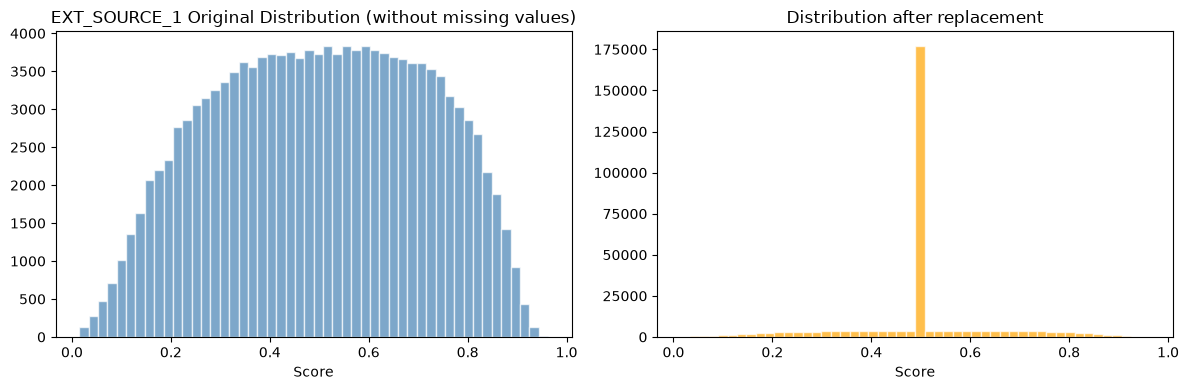

The ratio of missing values: 56.4%
Median: 0.506


In [6]:
import matplotlib.pyplot as plt

median_val = master['EXT_SOURCE_1'].median()
imputed = master['EXT_SOURCE_1'].fillna(median_val)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(master['EXT_SOURCE_1'].dropna(), bins=50,
             color='steelblue', alpha=0.7, edgecolor='white')
axes[0].set_title('EXT_SOURCE_1 Original Distribution (without missing values)')
axes[0].set_xlabel('Score')

axes[1].hist(imputed, bins=50,
             color='orange', alpha=0.7, edgecolor='white')
axes[1].set_title('Distribution after replacement')
axes[1].set_xlabel('Score')

plt.tight_layout()
plt.show()

print(f"The ratio of missing values: {master['EXT_SOURCE_1'].isna().mean():.1%}")
print(f"Median: {median_val:.3f}")

원본 `EXT_SOURCE_1` 분포는 0~1 사이에 비교적 넓게 분포해 있습니다. 이 때 중앙값으로 대체하면, 결측이었던 약 13만 건 전부(약 56.4%)가 같은 값(0.505 부근) 하나로 쌓여 분포 전체가 왜곡됩니다. 그 결과 실제로 0.505를 가진 고객과, 신용 이력이 없어 채워진 고객이 구분되지 않아 결측 자체가 가진 정보가 소실됩니다. 결측 자체가 신용 이력 부재를 시사하므로, 이 정보를 보존하는 방향으로 처리 전략을 다시 설계합니다

## Step 5. 결측 처리 전략 확정

결측 자체가 "신용 이력 부재"라는 유의미한 정보라는 점(Step 3~4)에서 출발해, 이 정보를 지우지 않고 모델이 다룰 수 있는 형태로 최대한 보존하는 방향으로 전략을 설계했습니다. 실현 방식은 모델군의 특성에 따라 다릅니다.

- **트리 기반 모델(LightGBM, XGBoost, CatBoost)**: 결측(NaN)을 그대로 두어 모델이 결측 여부 자체를 분기 신호로 활용하게 하고, `FLAG_EXT_SOURCE_MISSING`으로 "신용 이력 없음"이라는 신호를 별도로도 남겨둡니다.
- **Logistic Regression(선형 모델)**: 결측을 처리해야 학습이 가능합니다. 결측률이 높은 `EXT_SOURCE_1`(56.4%)은 중앙값 대체 시 분포가 심하게 왜곡되므로(Step 4), 정상 범위(0~1) 밖의 값인 **-1**로 대체해 결측 여부라는 정보성을 남겼습니다. 반면 결측률이 낮은 `EXT_SOURCE_2`, `EXT_SOURCE_3`, `EMPLOYMENT_YEARS`는 왜곡 위험이 작아 중앙값 대체를 유지했습니다.

모델이 결측을 처리하는 방식에 맞춰 정보 손실을 최소화하는 방향으로 진행했고, 이렇게 두 갈래로 저장한 데이터셋은 `03_modeling.ipynb`에서 모델군에 맞는 버전으로 각각 사용합니다.

## Step 6. 고객 단위 Stratified Split (80/20)

Step 1에서 시간 축이 없다는 것을 확인했으므로, `TARGET` 비율을 유지하는 고객 단위 랜덤 분할을 적용합니다.

In [7]:
from sklearn.model_selection import train_test_split

# categorical value 를 모델이 해석 가능한 numerical value로 변환 후 train/test 분리
binary_map = {'Y': 1, 'N': 0}
master['FLAG_OWN_CAR']    = master['FLAG_OWN_CAR'].map(binary_map)
master['FLAG_OWN_REALTY'] = master['FLAG_OWN_REALTY'].map(binary_map)

train_ids, val_ids = train_test_split(
    master['SK_ID_CURR'],
    test_size=0.2,
    random_state=42,
    stratify=master['TARGET']
)

train_df = master[master['SK_ID_CURR'].isin(train_ids)].copy()
val_df   = master[master['SK_ID_CURR'].isin(val_ids)].copy()

print(f"Train: {len(train_df):,}건, 부도율 {train_df['TARGET'].mean():.2%}")
print(f"Val:   {len(val_df):,}건, 부도율 {val_df['TARGET'].mean():.2%}")

Train: 246,008건, 부도율 8.07%
Val:   61,503건, 부도율 8.07%


## Step 7. 모델군별 데이터셋 생성 및 저장

Step 5에서 정한 전략대로 모델군별 특성에 맞춰 결측치 유지 버전과 -1 대체 버전을 만듭니다. 이 때, 중앙값 대체가 필요한 피처는 **Train에서만 계산하고 Validation에서는 그대로 적용**합니다. 이를 통해 검증 단계에서 분포 정보를 미리 보지 않게 되어 정보 누수를 막을 수 있고, 실제 운영 환경처럼 새로운 데이터에 같은 규칙을 적용하는 상황도 반영할 수 있습니다.

In [8]:
# 결측(NaN) 유지 데이터셋
train_raw = train_df.copy()
val_raw   = val_df.copy()

train_raw.to_csv('../data/train_raw.csv', index=False)
val_raw.to_csv('../data/val_raw.csv', index=False)

# -1 대체 데이터셋──
impute_cols = ['EMPLOYMENT_YEARS', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
medians = train_df[impute_cols].median()

train_lr = train_df.copy()
val_lr   = val_df.copy()

train_lr['EXT_SOURCE_1'] = train_lr['EXT_SOURCE_1'].fillna(-1)
val_lr['EXT_SOURCE_1']   = val_lr['EXT_SOURCE_1'].fillna(-1)

train_lr[impute_cols] = train_lr[impute_cols].fillna(medians)
val_lr[impute_cols]   = val_lr[impute_cols].fillna(medians)

train_lr.to_csv('../data/train_lr.csv', index=False)
val_lr.to_csv('../data/val_lr.csv', index=False)

print("저장 완료")
print(f"  train_raw.csv / val_raw.csv  (NaN 유지, 트리 모델용)")
print(f"  train_lr.csv  / val_lr.csv   (EXT_SOURCE_1=-1, 나머지 중앙값 대체, LR용)")

print(f"\nTrain 기준 중앙값: {medians.to_dict()}")
print(f"train_lr EXT_SOURCE_1 = -1 인 건수: {(train_lr['EXT_SOURCE_1'] == -1).sum():,}")

저장 완료
  train_raw.csv / val_raw.csv  (NaN 유지, 트리 모델용)
  train_lr.csv  / val_lr.csv   (EXT_SOURCE_1=-1, 나머지 중앙값 대체, LR용)

Train 기준 중앙값: {'EMPLOYMENT_YEARS': 4.52054794520548, 'EXT_SOURCE_2': 0.5658969639248427, 'EXT_SOURCE_3': 0.5370699579791587}
train_lr EXT_SOURCE_1 = -1 인 건수: 138,486


## Step 8. 최종 검증

Train/Validation 분할 후 핵심 정책 변수의 분포가 서로 일치하는지 확인합니다.

In [9]:
check_cols = ['DTI', 'CIR', 'LTV', 'AGE']

summary = pd.DataFrame({
    'train_mean': train_raw[check_cols].mean(),
    'val_mean':   val_raw[check_cols].mean(),
})
summary['diff'] = (summary['train_mean'] - summary['val_mean']).round(4)

print(summary.round(4))
print(f"\nTrain 부도율: {train_raw['TARGET'].mean():.4f}")
print(f"Val   부도율: {val_raw['TARGET'].mean():.4f}")

     train_mean  val_mean    diff
DTI      0.1809    0.1809 -0.0000
CIR      3.9591    3.9514  0.0077
LTV      1.1230    1.1229  0.0001
AGE     43.9257   43.9820 -0.0563

Train 부도율: 0.0807
Val   부도율: 0.0807


Train과 Validation 분할 후 DTI, CIR, LTV, AGE의 평균과 부도율이 거의 동일하게 유지되어, 핵심 정책 변수 기준으로는 분할 편향 신호가 보이지 않습니다. 이는 이후 모델 성능 차이가 분할 편향보다는 모델 자체의 일반화 성능에서 비롯됐다고 해석할 수 있는 근거가 됩니다.

## 다음 단계에서는

이 노트북에서는 관측 단위를 고객 단위로 재설계함에 따라 4개의 원천 데이터를 하나의 마스터 테이블로 처리했고, 결측치를 모델의 특성에 맞게 처리하면서 다음의 데이터셋을 얻게 되었습니다.

- `train_raw.csv` / `val_raw.csv`: 결측을 NaN으로 유지한 버전 — 트리 기반 모델(`03_modeling.ipynb`)에서 사용
- `train_lr.csv` / `val_lr.csv`: 결측률이 높은 변수는 -1로, 낮은 변수는 중앙값으로 대체한 버전 — Logistic Regression 베이스라인에서 사용

`02_eda_policy_design.ipynb`에서는 이 데이터를 바탕으로 DTI·CIR·LTV 등 정책 변수의 실제 기준치를 데이터로 검증합니다.